# REPLYNT Notebook 2: Priority Classifier

This notebook predicts `P1`, `P2`, or `P3` priority using a combination of TF-IDF text features and engineered business signals such as `contains_money`, `contains_deadline`, and `text_length`. It compares a balanced LinearSVC against XGBoost, reports full evaluation metrics, explains the winning model, and saves the trained pipeline as `priority_pipeline.pkl`.

In [1]:
import importlib
import subprocess
import sys

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "joblib": "joblib",
}

missing = []
for module_name, package_name in REQUIRED_PACKAGES.items():
    try:
        importlib.import_module(module_name)
    except ImportError:
        missing.append(package_name)

if missing:
    print("Installing missing packages:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("All base packages are already installed.")


try:
    import xgboost
    print("XGBoost already installed:", xgboost.__version__)
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])
    import xgboost
    print("Installed XGBoost:", xgboost.__version__)

All base packages are already installed.
Installed XGBoost: 3.2.0


In [2]:
from __future__ import annotations

import re
import warnings
from pathlib import Path
from typing import Iterable

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 160)

RANDOM_STATE = 42
BASE_DIR = Path.home() / "Desktop" / "replynt_final"
DATA_DIR = BASE_DIR / "data"
NOTEBOOK_DIR = BASE_DIR / "notebooks"
MODELS_DIR = BASE_DIR / "models"
NOTEBOOK_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data directory: {DATA_DIR}")
print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Model directory: {MODELS_DIR}")

from xgboost import XGBClassifier

Data directory: C:\Users\mbmeg\Desktop\replynt_final\data
Notebook directory: C:\Users\mbmeg\Desktop\replynt_final\notebooks
Model directory: C:\Users\mbmeg\Desktop\replynt_final\models


In [3]:
def normalize_text(value: str) -> str:
    if pd.isna(value):
        return ""
    text = str(value).replace("\r", " ").replace("\n", " ")
    text = re.sub(r"https?://\S+|www\.\S+", " URL ", text, flags=re.IGNORECASE)
    text = re.sub(r"\S+@\S+", " EMAIL ", text)
    text = re.sub(r"[^a-zA-Z0-9$%!?.,:/\\-]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip().lower()
    return text


def detect_csv(candidates: Iterable[str], required_columns: Iterable[str]) -> Path:
    required_columns = set(required_columns)
    candidates = [candidate.lower() for candidate in candidates]
    files = sorted(DATA_DIR.glob("*.csv"))

    for path in files:
        if any(candidate in path.name.lower() for candidate in candidates):
            preview = pd.read_csv(path, nrows=5)
            if required_columns.issubset(set(preview.columns)):
                return path

    for path in files:
        preview = pd.read_csv(path, nrows=5)
        if required_columns.issubset(set(preview.columns)):
            return path

    raise FileNotFoundError(
        f"Could not find a CSV in {DATA_DIR} matching names={candidates} and columns={sorted(required_columns)}"
    )


def safe_n_splits(y: pd.Series, default: int = 5) -> int:
    return max(2, min(default, int(y.value_counts().min())))


def metrics_frame(y_true, y_pred, average="macro") -> pd.DataFrame:
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average=average, zero_division=0),
        "recall": recall_score(y_true, y_pred, average=average, zero_division=0),
        "f1": f1_score(y_true, y_pred, average=average, zero_division=0),
    }
    return pd.DataFrame([metrics]).round(4)


def plot_confusion(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()
    return cm_df


def summarize_cv(results: dict, model_name: str) -> pd.DataFrame:
    frame = pd.DataFrame(results)
    keep = [col for col in frame.columns if col.startswith("test_")]
    summary = frame[keep].agg(["mean", "std"]).T.reset_index()
    summary.columns = ["metric", f"{model_name}_mean", f"{model_name}_std"]
    summary["metric"] = summary["metric"].str.replace("test_", "", regex=False)
    return summary

priority_path = detect_csv(["triage", "priority"], ["subject", "body", "priority"])
print(f"Using dataset: {priority_path}")

df = pd.read_csv(priority_path)
df["subject"] = df["subject"].fillna("")
df["body"] = df["body"].fillna("")
df["email_text"] = (df["subject"].astype(str) + " " + df["body"].astype(str)).map(normalize_text)
df["contains_money"] = df.get("contains_money", False).astype(str).str.lower().isin(["true", "1", "yes"])
df["contains_deadline"] = df.get("contains_deadline", False).astype(str).str.lower().isin(["true", "1", "yes"])
df["text_length"] = df["email_text"].str.len()
df["priority"] = df["priority"].astype(str).str.strip()
df = df[df["priority"].isin(["P1", "P2", "P3"])].reset_index(drop=True)

label_map = {"P1": 0, "P2": 1, "P3": 2}
inverse_label_map = {value: key for key, value in label_map.items()}

display(df[["subject", "body", "priority", "contains_money", "contains_deadline", "text_length"]].head())
display(df["priority"].value_counts().to_frame("count"))

Using dataset: C:\Users\mbmeg\Desktop\replynt_final\data\triage_train_FINAL.csv


,subject,body,priority,contains_money,contains_deadline,text_length
0,July product roundup,"Hello readers, welcome to our July newsletter. This edition highlights customer stories, a few customer wins, and several practical tips from the team.",P3,False,False,172
1,Would 2:30 PM on by EOD work?,"Hi Alex, I would like to set up a meeting to discuss launch readiness. Please share a convenient time this week.",P2,False,True,142
2,Idea to help Brightline Logistics surface urgent issues sooner,"Hi Reese, if you are exploring ways to streamline the marketing workflow, I would love to show how we support teams like Brightline Logistics.",P2,False,True,205
3,Quote request for data warehouse,"Hello, could you share a formal quote for the data warehouse and any annual pricing details? The finance team needs the numbers this week.",P1,True,False,171
4,Friendly reminder: outstanding balance on INV-03828,"Hello Casey, this is a reminder that invoice INV-03828 for $8,200 is due April 28. Please confirm the payment timing so we can update our records.",P1,True,True,198


,count
priority,
P2,3732
P1,3103
P3,1982


In [18]:
df["contains_money"] = df["contains_money"].astype(int)
df["contains_deadline"] = df["contains_deadline"].astype(int)

X = df[["email_text", "contains_money", "contains_deadline", "text_length"]].copy()
y = df["priority"].map(label_map)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

cv = StratifiedKFold(
    n_splits=safe_n_splits(pd.Series(y_train), default=5),
    shuffle=True,
    random_state=RANDOM_STATE,
)

In [19]:
text_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.98,
    sublinear_tf=True,
    strip_accents="unicode",
)

feature_builder = ColumnTransformer(
    transformers=[
        ("text", text_vectorizer, "email_text"),
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler(with_mean=False)),
                ]
            ),
            ["text_length"],
        ),
        ("flags", SimpleImputer(strategy="most_frequent"), ["contains_money", "contains_deadline"]),
    ]
)

linear_svc_pipeline = Pipeline(
    steps=[
        ("features", feature_builder),
        ("classifier", LinearSVC(class_weight="balanced", random_state=RANDOM_STATE)),
    ]
)

xgb_pipeline = Pipeline(
    steps=[
        ("features", feature_builder),
        (
            "classifier",
            XGBClassifier(
                objective="multi:softprob",
                num_class=3,
                n_estimators=250,
                max_depth=6,
                learning_rate=0.08,
                subsample=0.9,
                colsample_bytree=0.8,
                min_child_weight=2,
                reg_lambda=1.0,
                eval_metric="mlogloss",
                random_state=RANDOM_STATE,
                n_jobs=4,
                tree_method="hist",
            ),
        ),
    ]
)

models = {"LinearSVC": linear_svc_pipeline, "XGBoost": xgb_pipeline}
scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro",
}

cv_tables = []
cv_scores = {}
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    cv_tables.append(summarize_cv(scores, name))
    cv_scores[name] = scores["test_f1"].mean()

cv_report = cv_tables[0]
for table in cv_tables[1:]:
    cv_report = cv_report.merge(table, on="metric", how="outer")

display(cv_report.round(4))
best_model_name = max(cv_scores, key=cv_scores.get)
best_model = models[best_model_name]
print("Selected model:", best_model_name)

,metric,LinearSVC_mean,LinearSVC_std,XGBoost_mean,XGBoost_std
0,accuracy,0.8606,0.0145,0.8620,0.0142
1,f1,0.8790,0.0125,0.8795,0.0125
2,precision,0.8793,0.0127,0.8808,0.0131
3,recall,0.8788,0.0123,0.8787,0.0120


Selected model: XGBoost


,accuracy,precision,recall,f1
0,0.8668,0.8866,0.8821,0.8835


              precision    recall  f1-score   support

          P1       0.84      0.77      0.80       621
          P2       0.82      0.88      0.85       747
          P3       1.00      1.00      1.00       396

    accuracy                           0.87      1764
   macro avg       0.89      0.88      0.88      1764
weighted avg       0.87      0.87      0.87      1764



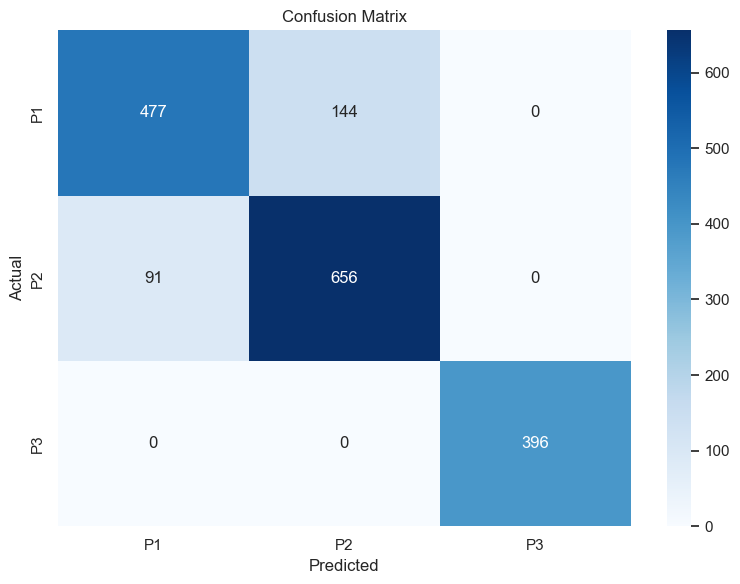

,P1,P2,P3
P1,477,144,0
P2,91,656,0
P3,0,0,396


In [20]:
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

y_test_labels = pd.Series(y_test).map(inverse_label_map)
y_pred_labels = pd.Series(y_pred).map(inverse_label_map)

display(metrics_frame(y_test_labels, y_pred_labels, average="macro"))
print(classification_report(y_test_labels, y_pred_labels, zero_division=0))
confusion_df = plot_confusion(y_test_labels, y_pred_labels, labels=["P1", "P2", "P3"])
display(confusion_df)

## Explainability

LinearSVC exposes class-wise coefficients, while XGBoost exposes feature importances. The code below adapts to whichever model wins.

In [21]:
feature_names = best_model.named_steps["features"].get_feature_names_out()
classifier = best_model.named_steps["classifier"]

if best_model_name == "LinearSVC":
    coef_frame = pd.DataFrame(classifier.coef_.T, index=feature_names, columns=["P1", "P2", "P3"])
    for label in ["P1", "P2", "P3"]:
        print(f"Top features for {label}")
        display(coef_frame[label].sort_values(ascending=False).head(15).reset_index().rename(columns={"index": "feature", label: "weight"}))
else:
    importance = pd.DataFrame({"feature": feature_names, "importance": classifier.feature_importances_})
    display(importance.sort_values("importance", ascending=False).head(25))

,feature,importance
4022,text__hello everyone,0.038499
3753,text__fyi,0.027454
2981,text__edition,0.019234
4473,text__includes,0.018097
4782,text__inv,0.018023
5433,text__like,0.017270
8321,text__shipped,0.016592
5107,text__is still,0.014547
10425,text__when convenient,0.014432
7426,text__readers,0.014077


In [22]:
model_path = MODELS_DIR / "priority_pipeline.pkl"
joblib.dump(best_model, model_path)
print(f"Saved model to: {model_path}")

Saved model to: C:\Users\mbmeg\Desktop\replynt_final\models\priority_pipeline.pkl


In [24]:
sample_email = pd.DataFrame(
    {
        "email_text": [
            normalize_text(
                "Urgent: please approve the payment request by 5 PM today so finance can process it."
            )
        ],
        "contains_money": [1],
        "contains_deadline": [1],
        "text_length": [78]
    }
)

predicted_priority = pd.Series(
    best_model.predict(sample_email)
).map(inverse_label_map)

print(predicted_priority)

0    P2
dtype: object
